In [ ]:
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.5 MB/s eta 0:00:00


In [ ]:
import timm
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import random_split
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader
from torchvision import transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the dataset from Kaggle
!kaggle datasets download -d msambare/fer2013

# Unzip the dataset
!unzip -q fer2013.zip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.34GB/s]


In [ ]:
# --- Define Paths and Transformations ---
full_train_dir = '/content/train'
test_dir = '/content/test'

data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

# --- Load and Split the Training Data ---

# 1. Load the entire original training dataset
full_train_dataset_unsplit = ImageFolder(full_train_dir, transform=data_transforms['train'])
print(f"Total images in original training directory: {len(full_train_dataset_unsplit)}")

# 2. Define the split sizes (80% for training, 20% for validation)
val_size = int(0.2 * len(full_train_dataset_unsplit))
train_size = len(full_train_dataset_unsplit) - val_size

# 3. Perform the split
train_dataset, val_dataset = random_split(full_train_dataset_unsplit, [train_size, val_size])

# IMPORTANT: The validation set should NOT use training augmentations (like random flips).
# We need to assign the correct 'val_test' transform to our new validation subset.
val_dataset.dataset.transform = data_transforms['val_test']

print(f"New training set size: {len(train_dataset)}")
print(f"New validation set size: {len(val_dataset)}")


# --- Load the Test Data ---
# This remains a separate, untouched set for final evaluation.
test_dataset = ImageFolder(test_dir, transform=data_transforms['val_test'])
print(f"Test set size: {len(test_dataset)}")


# --- Create DataLoaders ---
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Get class names for later use in evaluation
class_names = full_train_dataset_unsplit.classes
num_classes = len(class_names)
print(f"\nClasses found: {class_names}")

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Hitung Class Weights (dari sel data loading) ---
train_labels = [label for _, label in train_dataset]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights: {class_weights_tensor}")

Total images in original training directory: 28709
New training set size: 22968
New validation set size: 5741
Test set size: 7178

Classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Using device: cuda
Class Weights: tensor([1.0279, 8.9649, 1.0025, 0.5678, 0.8298, 0.8547, 1.2792],
       device='cuda:0')


In [ ]:
# --- Step 5: Define the Model (Fine-Tuning EfficientNet-B0) ---

num_classes = len(full_train_dataset_unsplit.classes)
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)

# --- Fine-Tuning Strategy: Freeze all layers first ---
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last 3 blocks, the head, and the classifier
layers_to_unfreeze = [model.blocks[4], model.blocks[5], model.blocks[6],
                      model.conv_head, model.bn2, model.classifier]

for layer in layers_to_unfreeze:
    for param in layer.parameters():
        param.requires_grad = True

model = model.to(device)

# --- Definisikan Optimizer untuk melatih SEMUA parameter yang tidak dibekukan ---
# Kita perlu mengumpulkan semua parameter yang `requires_grad = True`
params_to_update = [p for p in model.parameters() if p.requires_grad]


optimizer = optim.AdamW(params_to_update, lr=1e-4, weight_decay=1e-2) # Coba lr 1e-4 atau 1e-5
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3, verbose=True)

print("\n--- Konfigurasi Training Lanjutan ---")
print(f"Optimizer: AdamW")
print(f"Learning Rate Awal: {optimizer.defaults['lr']}")
print(f"Loss Function: Weighted CrossEntropyLoss")
print(f"Scheduler: ReduceLROnPlateau")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


--- Konfigurasi Training Lanjutan ---
Optimizer: AdamW
Learning Rate Awal: 0.0001
Loss Function: Weighted CrossEntropyLoss
Scheduler: ReduceLROnPlateau


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
# Training loop
num_epochs = 30
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels.data)

    epoch_val_loss = running_loss / len(val_loader.dataset)
    scheduler.step(epoch_val_loss)
    epoch_val_acc = correct_preds.double() / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc.item())

    print(f"Epoch {epoch+1}/{num_epochs} -> "
          f"Train Loss: {epoch_train_loss:.4f}, "
          f"Val Loss: {epoch_val_loss:.4f}, "
          f"Val Acc: {epoch_val_acc:.4f}")

print("\nFinished Training!")

Epoch 1/30 [Validation]: 100%|██████████| 180/180 [00:18<00:00,  9.69it/s]


Epoch 1/30 -> Train Loss: 1.8639, Val Loss: 1.4373, Val Acc: 0.4902


Epoch 2/30 [Validation]: 100%|██████████| 180/180 [00:18<00:00,  9.98it/s]


Epoch 2/30 -> Train Loss: 0.9258, Val Loss: 1.3845, Val Acc: 0.5494


Epoch 3/30 [Validation]: 100%|██████████| 180/180 [00:18<00:00, 10.00it/s]


...

Epoch 28/30 -> Train Loss: 0.0167, Val Loss: 1.8536, Val Acc: 0.6065


Epoch 29/30 [Validation]: 100%|██████████| 180/180 [00:16<00:00, 10.60it/s]


Epoch 29/30 -> Train Loss: 0.0166, Val Loss: 1.8489, Val Acc: 0.6086


Epoch 30/30 [Validation]: 100%|██████████| 180/180 [00:17<00:00, 10.38it/s]

Epoch 30/30 -> Train Loss: 0.0172, Val Loss: 1.8574, Val Acc: 0.6072

Finished Training!


Evaluating on Test Set: 100%|██████████| 225/225 [00:21<00:00, 10.53it/s]


--- Full Classification Report ---
              precision    recall  f1-score      support
angry          0.533493  0.465553  0.497213   958.000000
disgust        0.662500  0.477477  0.554974   111.000000
fear           0.505178  0.428711  0.463814  1024.000000
happy          0.792084  0.846110  0.818207  1774.000000
neutral        0.535819  0.594485  0.563629  1233.000000
sad            0.480509  0.484362  0.482428  1247.000000
surprise       0.734250  0.771360  0.752347   831.000000
accuracy       0.615352  0.615352  0.615352     0.615352
macro avg      0.606262  0.581151  0.590373  7178.000000
weighted avg   0.609795  0.615352  0.611050  7178.000000

--- Overall Test Set Metrics ---
Overall Accuracy: 61.54%
Macro Average Precision: 0.606
Macro Average Recall: 0.581
Macro Average F1-Score: 0.590


Weighted Average Precision: 0.610
Weighted Average Recall: 0.615
Weighted Average F1-Score: 0.611


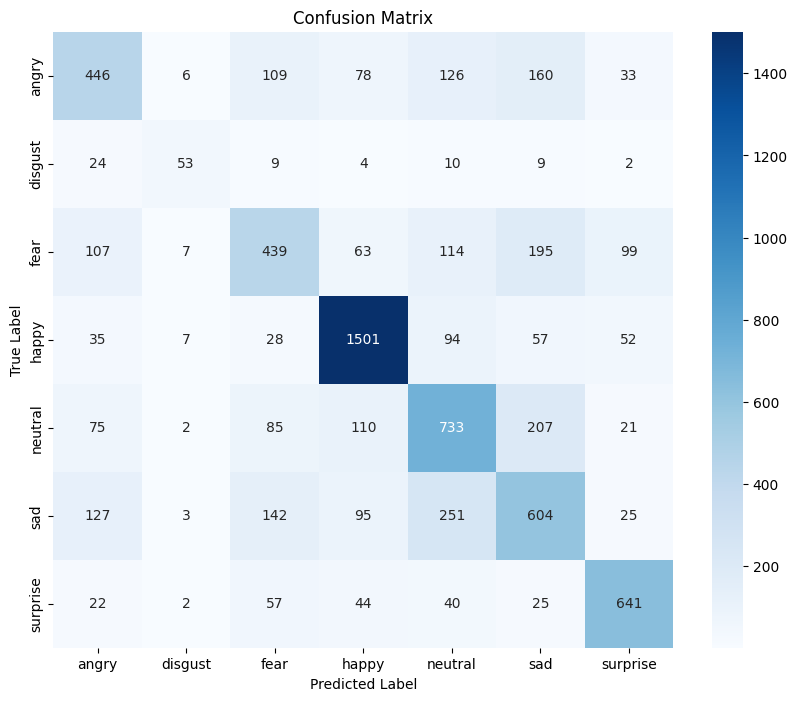

In [ ]:
def evaluate_model(model, data_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating on Test Set"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

# Get predictions
y_true, y_pred = evaluate_model(model, test_loader, device)

# --- Metrics ---
# Use output_dict=True to get a dictionary of metrics
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print("--- Full Classification Report ---")
print(df_report)

# --- Overall Metrics ---
# You can get these directly from the report dictionary
# 'macro avg' computes the metric independently for each class and then takes the average.
# 'weighted avg' computes the metric for each class, but weights the average by the number of true instances for each class.
overall_accuracy = report['accuracy']
macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1 = report['macro avg']['f1-score']

weighted_precision = report['weighted avg']['precision']
weighted_recall = report['weighted avg']['recall']
weighted_f1 = report['weighted avg']['f1-score']

print("\n--- Overall Test Set Metrics ---")
print(f"Overall Accuracy: {overall_accuracy * 100:.2f}%")
print(f"Macro Average Precision: {macro_precision:.3f}")
print(f"Macro Average Recall: {macro_recall:.3f}")
print(f"Macro Average F1-Score: {macro_f1:.3f}")
print("\n")
print(f"Weighted Average Precision: {weighted_precision:.3f}")
print(f"Weighted Average Recall: {weighted_recall:.3f}")
print(f"Weighted Average F1-Score: {weighted_f1:.3f}")


# --- Confusion Matrix (This part remains the same) ---
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Define the path to save the model
save_path = "/content/drive/MyDrive/model ml/emotion recognition/EmotionRecognition1.7.0/best.pt"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the model's state dictionary
torch.save(model.state_dict(), save_path)

print(f"Model saved successfully to {save_path}")

# To load the model later:
# model.load_state_dict(torch.load(save_path))
# model.eval()

Model saved successfully to /content/drive/MyDrive/model ml/emotion recognition/EmotionRecognition1.7.0/best.pt
